In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Emotion_classify_Data.csv')
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [3]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer

le = LabelEncoder()
df['Emotion'] = le.fit_transform(df['Emotion'])
classes = len(le.classes_)

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Comment'])
seq = tokenizer.texts_to_sequences(df['Comment'])

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

max_len = max(len(i) for i in seq)
X = pad_sequences(seq, maxlen = max_len)
y = to_categorical(df['Emotion'], num_classes=classes)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape,y_train.shape)

(4749, 64) (4749, 3)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=max_len),
    GRU(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.3545 - loss: 1.0957 - val_accuracy: 0.5000 - val_loss: 1.0445
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6415 - loss: 0.8825 - val_accuracy: 0.8190 - val_loss: 0.4964
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9361 - loss: 0.2276 - val_accuracy: 0.8965 - val_loss: 0.2926
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9829 - loss: 0.0740 - val_accuracy: 0.9032 - val_loss: 0.2882
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9879 - loss: 0.0461 - val_accuracy: 0.9007 - val_loss: 0.3497
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9930 - loss: 0.0275 - val_accuracy: 0.9150 - val_loss: 0.3232
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9970 - loss: 0.0143 - val_accuracy: 0.9158 - val_loss: 0.3830
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9959 - loss: 0.0184 - val_accuracy: 0.9234 - val_lo

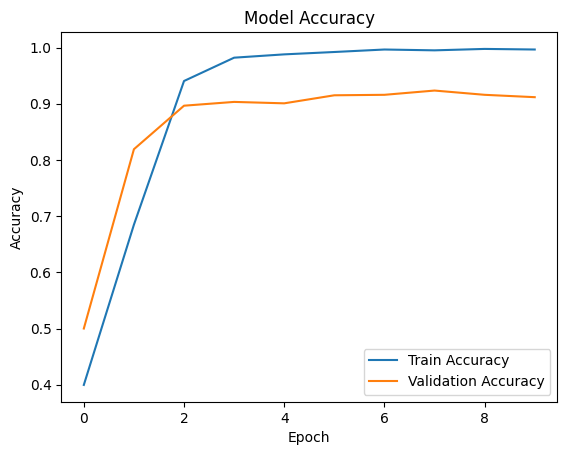

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [10]:
def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model.predict(padded)
    emotion = le.inverse_transform([np.argmax(pred)])
    return emotion[0]

In [11]:
print(predict_emotion("fuck,what is this!"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
anger
